In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/tables", exist_ok=True)

In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Train veri boyutu:", train_df.shape)
print("External test veri boyutu:", test_df.shape)

Train veri boyutu: (103904, 25)
External test veri boyutu: (25976, 25)


In [3]:
train_df = train_df.drop(columns=["Unnamed: 0", "id"], errors="ignore")
test_df = test_df.drop(columns=["Unnamed: 0", "id"], errors="ignore")

arrival_delay_median = train_df["Arrival Delay in Minutes"].median()

train_df["Arrival Delay in Minutes"] = train_df["Arrival Delay in Minutes"].fillna(arrival_delay_median)
test_df["Arrival Delay in Minutes"] = test_df["Arrival Delay in Minutes"].fillna(arrival_delay_median)

train_df["satisfaction"] = train_df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

test_df["satisfaction"] = test_df["satisfaction"].map({
    "neutral or dissatisfied": 0,
    "satisfied": 1
})

print("Temizlenmiş train boyutu:", train_df.shape)
print("Temizlenmiş external test boyutu:", test_df.shape)

Temizlenmiş train boyutu: (103904, 23)
Temizlenmiş external test boyutu: (25976, 23)


In [4]:
X_train = train_df.drop("satisfaction", axis=1)
y_train = train_df["satisfaction"]

X_test_external = test_df.drop("satisfaction", axis=1)
y_test_external = test_df["satisfaction"]

In [5]:
categorical_features = X_train.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X_train.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Kategorik sütunlar:", categorical_features)
print("Sayısal sütun sayısı:", len(numeric_features))



Kategorik sütunlar: ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Sayısal sütun sayısı: 18


In [6]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [7]:
def evaluate_external_model(model_name, model, X_train, X_test, y_train, y_test):
    # Modeli train verisi ile eğit
    model.fit(X_train, y_train)

    # External test verisi üzerinde tahmin yap
    y_pred = model.predict(X_test)

    # Metrikleri hesapla
    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "F2-score": fbeta_score(y_test, y_pred, beta=2)
    }

    # Sonuçları yazdır
    print(f"\n{model_name} - External Test Sonuçları")
    print("-" * 50)
    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1-score : {metrics['F1-score']:.4f}")
    print(f"F2-score : {metrics['F2-score']:.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    return metrics, y_pred

In [8]:
log_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

log_metrics, y_pred_log_ext = evaluate_external_model(
    "Logistic Regression",
    log_model,
    X_train, X_test_external, y_train, y_test_external
)


Logistic Regression - External Test Sonuçları
--------------------------------------------------
Accuracy : 0.8718
Precision: 0.8694
Recall   : 0.8333
F1-score : 0.8509
F2-score : 0.8403

Confusion Matrix:
[[13145  1428]
 [ 1901  9502]]


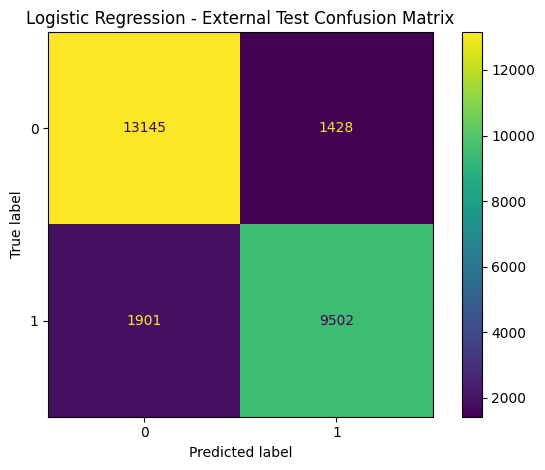

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test_external, y_pred_log_ext, values_format="d")
plt.title("Logistic Regression - External Test Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/external_confusion_matrix_lr.png", dpi=300)
plt.show()

In [9]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_metrics, y_pred_rf_ext = evaluate_external_model(
    "Random Forest",
    rf_model,
    X_train, X_test_external, y_train, y_test_external
)


Random Forest - External Test Sonuçları
--------------------------------------------------
Accuracy : 0.9634
Precision: 0.9729
Recall   : 0.9430
F1-score : 0.9577
F2-score : 0.9488

Confusion Matrix:
[[14273   300]
 [  650 10753]]


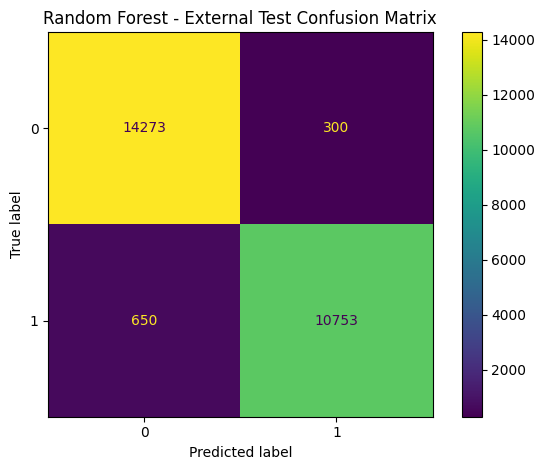

In [15]:
ConfusionMatrixDisplay.from_predictions(y_test_external, y_pred_rf_ext, values_format="d")
plt.title("Random Forest - External Test Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/external_confusion_matrix_rf.png", dpi=300)
plt.show()

In [11]:
knn_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", KNeighborsClassifier(n_neighbors=5))
])

knn_metrics, y_pred_knn_ext = evaluate_external_model(
    "kNN",
    knn_model,
    X_train, X_test_external, y_train, y_test_external
)


kNN - External Test Sonuçları
--------------------------------------------------
Accuracy : 0.9292
Precision: 0.9447
Recall   : 0.8910
F1-score : 0.9171
F2-score : 0.9012

Confusion Matrix:
[[13978   595]
 [ 1243 10160]]


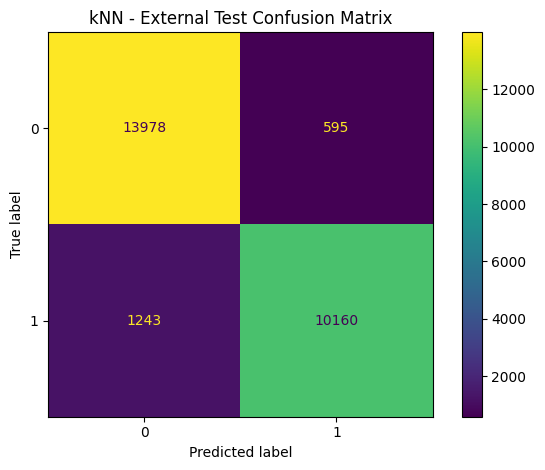

In [16]:
ConfusionMatrixDisplay.from_predictions(y_test_external, y_pred_knn_ext, values_format="d")
plt.title("kNN - External Test Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/external_confusion_matrix_knn.png", dpi=300)
plt.show()

In [12]:
nb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", GaussianNB())
])

nb_metrics, y_pred_nb_ext = evaluate_external_model(
    "Naive Bayes",
    nb_model,
    X_train, X_test_external, y_train, y_test_external
)


Naive Bayes - External Test Sonuçları
--------------------------------------------------
Accuracy : 0.8441
Precision: 0.8292
Recall   : 0.8122
F1-score : 0.8206
F2-score : 0.8156

Confusion Matrix:
[[12665  1908]
 [ 2141  9262]]


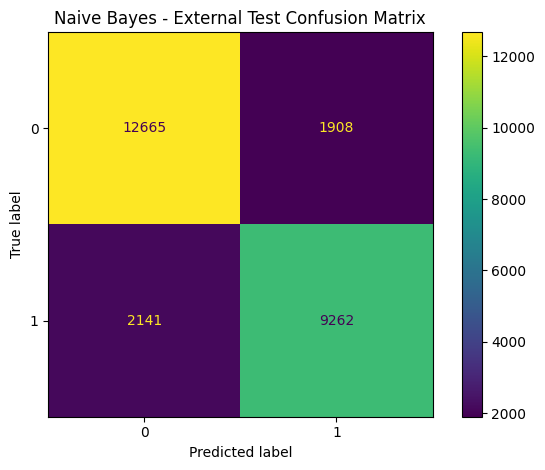

In [17]:
ConfusionMatrixDisplay.from_predictions(y_test_external, y_pred_nb_ext, values_format="d")
plt.title("Naive Bayes - External Test Confusion Matrix")
plt.tight_layout()
plt.savefig("../outputs/figures/external_confusion_matrix_nb.png", dpi=300)
plt.show()

In [13]:
external_results_df = pd.DataFrame([
    log_metrics,
    rf_metrics,
    knn_metrics,
    nb_metrics
])

external_results_df = external_results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

external_results_df.to_csv("../outputs/tables/model_results_external_test.csv", index=False)

print("External Test Sonuç Tablosu:")
display(external_results_df)

External Test Sonuç Tablosu:


,Model,Accuracy,Precision,Recall,F1-score,F2-score
0,Random Forest,0.963428,0.972858,0.942997,0.957695,0.948822
1,kNN,0.929242,0.944677,0.890994,0.917050,0.901237
2,Logistic Regression,0.871843,0.869350,0.833289,0.850938,0.840260
3,Naive Bayes,0.844125,0.829185,0.812242,0.820626,0.815575
